In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/azid_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2387,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2353,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1664,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1462,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1090,2


In [3]:
df.response.value_counts()

0    706
2    240
Name: response, dtype: int64

In [4]:
# number of sequences
Nseq = len(df)
Nseq

946

In [5]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [6]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

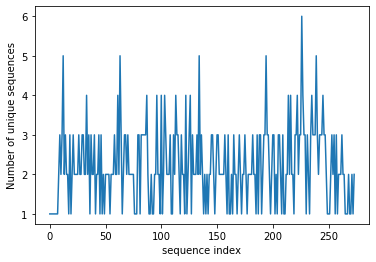

In [7]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [8]:
len(df.sequence.unique())

849

In [9]:
len(df)

946

In [10]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

37


,sequence,count,response,first_stop
72,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,62,2,122
89,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,53,2,50
96,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,51,2,87
107,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,49,2,87
120,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPHG...,47,2,63
124,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,46,2,170
141,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,43,2,214
154,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,41,2,122
171,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMVIVPDG...,39,2,195
173,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPHG...,39,2,63


In [11]:
df[df.sequence == WT]

,sequence,count,response,first_stop
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2353,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,515,0,273


In [12]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2387,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2353,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1664,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1462,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1090,2


In [13]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2387,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2353,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1664,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1462,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1090,2


In [14]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,590
2,227


In [15]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2353,2


In [16]:
# drop the start and stop codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT)-1))

## Ordinal regression

In [17]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
import mord
from mord import LogisticAT

In [18]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now
X = enc.fit_transform(design_cols)
print(X.shape)
X

(817, 583)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [19]:
enc.get_feature_names().size

583

In [20]:
y = df_unique.response.to_numpy()

In [21]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model.fit(X, y)
model.score(X, y)

ValueError: Values in y must be [0 1], instead got [0 2]

In [ ]:
model = Ridge(alpha=1.0)
model.fit(X,y)
model.score(X, y)

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [ ]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=model, param_grid=dict(alpha=alphas), cv=5, iid='deprecated')
grid_cv.fit(X, y)

In [ ]:
grid_cv.cv_results_

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
grid_cv.best_score_

In [ ]:
# regularization parameter picked by CV
grid_cv.best_params_

In [ ]:
best_coefs = grid_cv.best_estimator_.coef_
plt.plot(best_coefs, 'o')

In [ ]:
best_results = pd.DataFrame({'feature':enc.get_feature_names(), 'coef':best_coefs})

In [ ]:
best_results.sort_values('coef', ascending=False).head(10)

In [ ]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(33)

In [ ]:
show_design_response(191)

In [ ]:
best_results.sort_values('coef', ascending=True).head(10)

In [ ]:
show_design_response(238)

In [ ]:
show_design_response(214)

In [ ]:
pd.set_option('display.max_rows', 1000)
best_results